Classification Accuracy: 0.8333333333333334


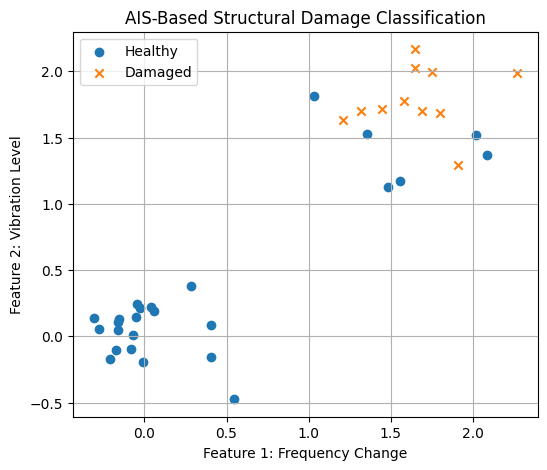

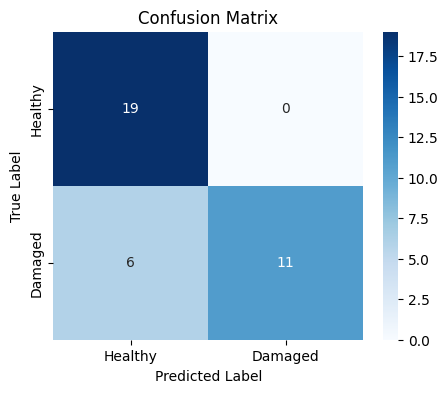

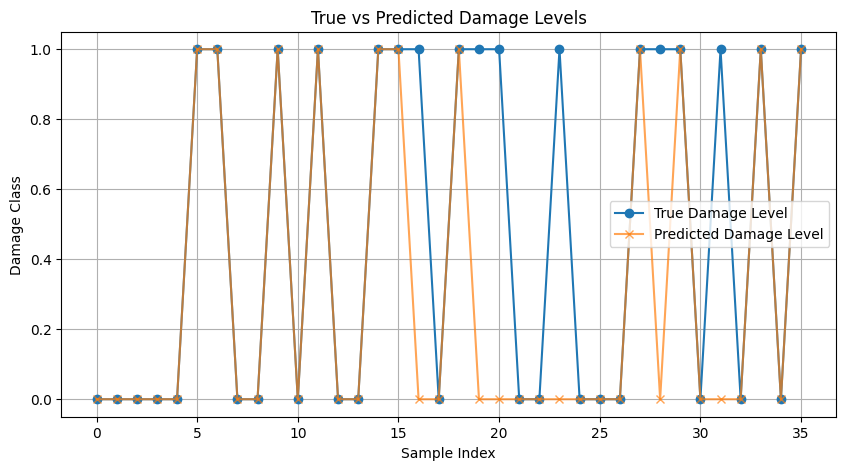

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Step 1: Generate Structural Data
# -----------------------------
np.random.seed(1)

# Features: frequency change, vibration level, strain variation
healthy = np.random.normal(0, 0.25, (60, 3))
damaged = np.random.normal(1.6, 0.35, (60, 3))

X = np.vstack((healthy, damaged))
y = np.array([0]*60 + [1]*60)  # 0 = Healthy, 1 = Damaged

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Step 2: Artificial Immune System (Negative Selection)
# -----------------------------
def generate_detectors(self_data, num_detectors=25, threshold=0.9):
    detectors = []
    while len(detectors) < num_detectors:
        detector = np.random.uniform(-2, 3, self_data.shape[1])
        distances = np.linalg.norm(self_data - detector, axis=1)
        if np.min(distances) > threshold:
            detectors.append(detector)
    return np.array(detectors)

def classify(sample, detectors, threshold=0.9):
    distances = np.linalg.norm(detectors - sample, axis=1)
    return 1 if np.min(distances) < threshold else 0

# -----------------------------
# Step 3: Training and Testing
# -----------------------------
detectors = generate_detectors(X_train[y_train == 0])

y_pred = np.array([classify(x, detectors) for x in X_test])

accuracy = accuracy_score(y_test, y_pred)
print("Classification Accuracy:", accuracy)

# -----------------------------
# Step 4: Classification Output Plot
# -----------------------------
plt.figure(figsize=(6, 5))

plt.scatter(
    X_test[y_pred == 0, 0],
    X_test[y_pred == 0, 1],
    marker='o',
    label='Healthy'
)

plt.scatter(
    X_test[y_pred == 1, 0],
    X_test[y_pred == 1, 1],
    marker='x',
    label='Damaged'
)

plt.xlabel("Feature 1: Frequency Change")
plt.ylabel("Feature 2: Vibration Level")
plt.title("AIS-Based Structural Damage Classification")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Step 5: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Healthy', 'Damaged'],
    yticklabels=['Healthy', 'Damaged']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Step 6: True vs Predicted Plot
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(y_test, label='True Damage Level', marker='o')
plt.plot(y_pred, label='Predicted Damage Level', marker='x', alpha=0.7)

plt.xlabel("Sample Index")
plt.ylabel("Damage Class")
plt.title("True vs Predicted Damage Levels")
plt.legend()
plt.grid()
plt.show()